In [6]:
# Nguyễn Hoàng Tùng

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow.keras import layers, models

# ========== a. Build Dataset ==========
np.random.seed(42)
n = 1000
jobs = np.random.choice(["Student","Engineer","Doctor","Teacher","Worker"], size=n)
ages = np.random.randint(18, 60, size=n)
heights = np.random.randint(150, 200, size=n)
weights = np.random.randint(45, 120, size=n)

bmi = weights / ((heights/100)**2)
labels = np.where(bmi < 18.5, "underweight", np.where(bmi < 25, "normal", "overweight"))

df = pd.DataFrame({"job":jobs, "age":ages, "height":heights, "weight":weights, "label":labels})
path_csv = r"D:\lecture\PTIT\20251\IntSys\data_4.1.csv"
os.makedirs(os.path.dirname(path_csv), exist_ok=True)
df.to_csv(path_csv, index=False)


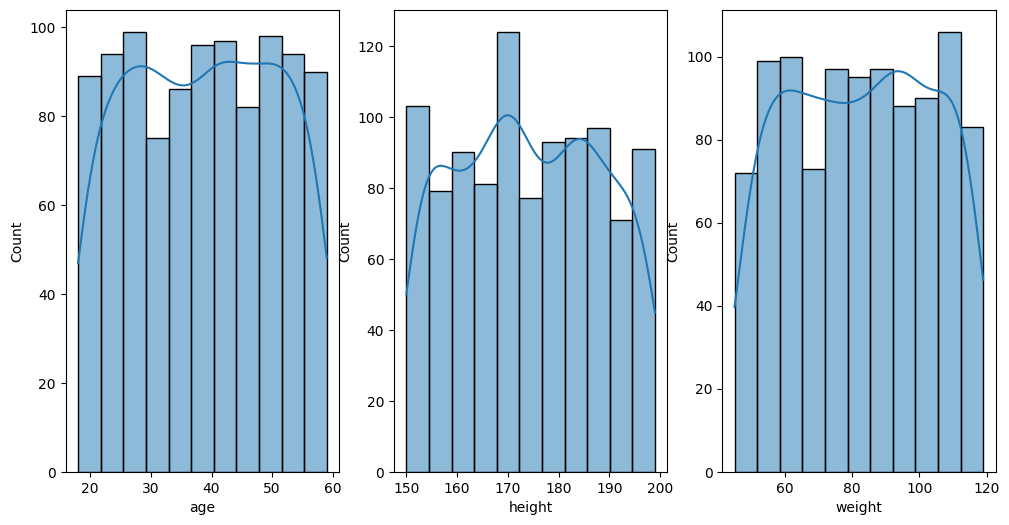

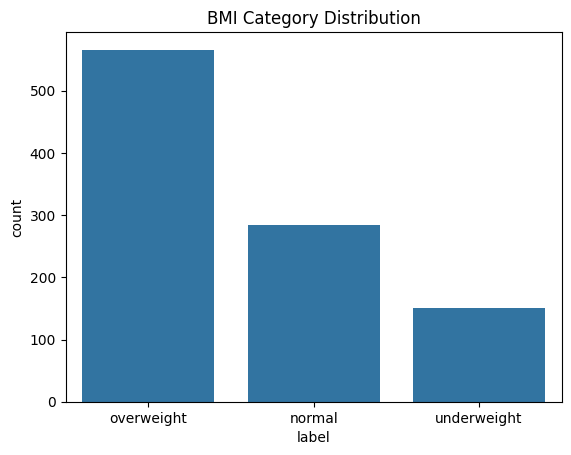

C:\Users\Admin\AppData\Local\Temp\ipykernel_15972\3760037753.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["job"] = job_encoder.fit_transform(X["job"])
C:\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super()._

Training CNN...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Training RNN...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Training LSTM...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
              Accuracy    MAE    MSE      RMSE
LogReg           0.980  0.025  0.035  0.187083
DecisionTree     0.945  0.065  0.085  0.291548
RandomForest     0.980  0.025  0.035  0.187083
SVM              0.970  0.035  0.045  0.212132
KNN              0.930  0.085  0.115  0.339116
CNN              0.975  0.040  0.070  0.264575
RNN              0.975  0.035  0.055  0.234521
LSTM             0.970  0.045  0.075  0.273861


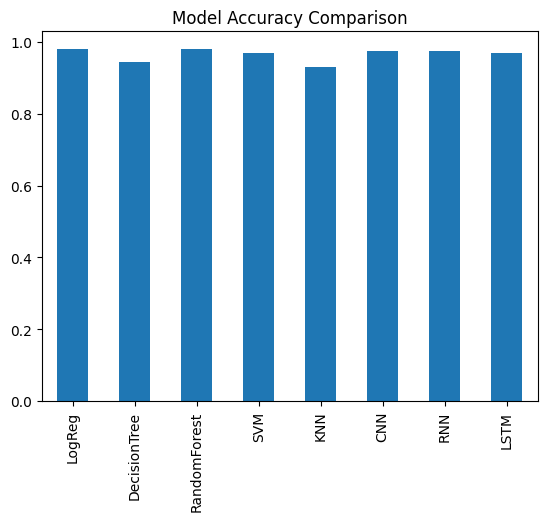

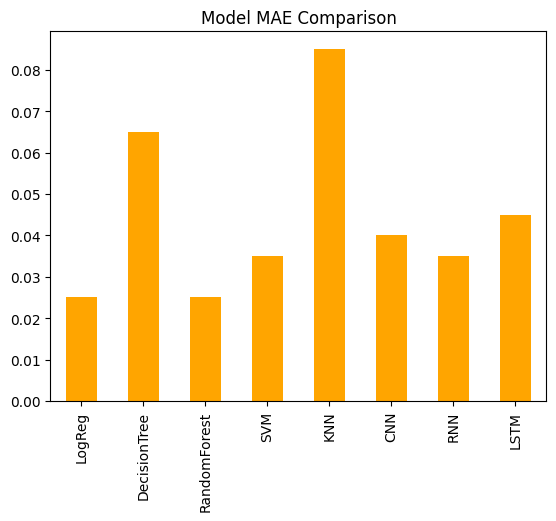

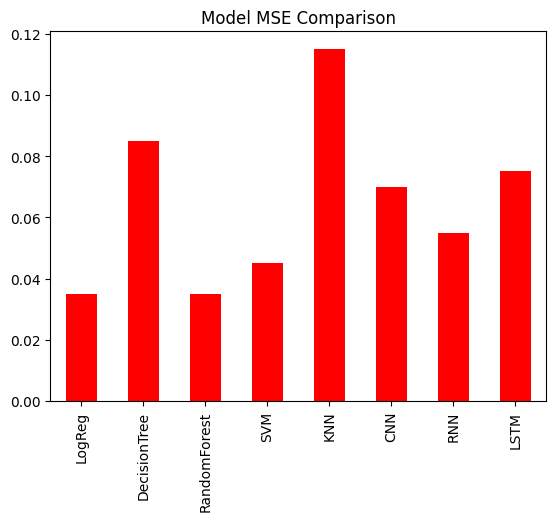

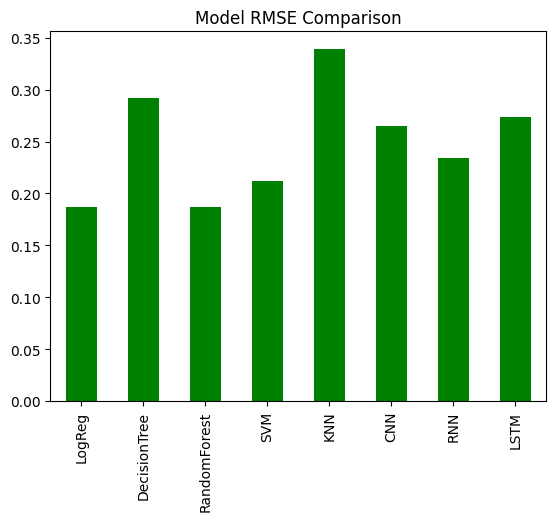

Best Model: LogReg


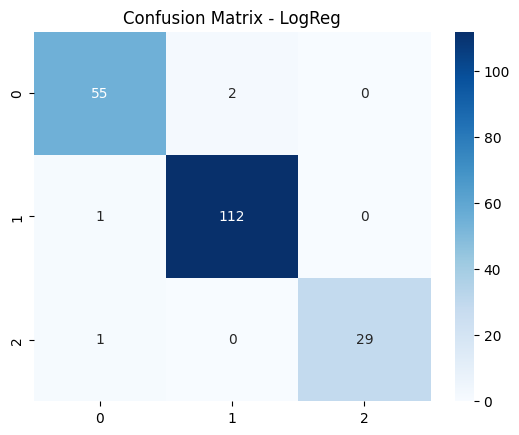

Prediction: overweight
Health Guide: Reduce sugar, increase physical activity.


In [8]:
# Nguyễn Hoàng Tùng

# ========== b. Show distribution ==========
plt.figure(figsize=(12,6))
for i,col in enumerate(["age","height","weight"]):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True)
plt.show()

sns.countplot(x="label", data=df)
plt.title("BMI Category Distribution")
plt.show()

# ========== Preprocessing ==========
X = df[["job","age","height","weight"]]
y = df["label"]

job_encoder = LabelEncoder()
X["job"] = job_encoder.fit_transform(X["job"])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # encode labels separately

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ========== c. ML Models ==========
ml_models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = {}
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    results[name] = [acc, mae, mse, rmse]

# ========== d. DL Models (CNN, RNN, LSTM) ==========
num_classes = len(np.unique(y))
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

X_train_dl = np.expand_dims(X_train, -1)  # shape (None, 4, 1)
X_test_dl = np.expand_dims(X_test, -1)

def build_cnn():
    model = models.Sequential([
        layers.Conv1D(32, 2, activation="relu", input_shape=(4,1)),
        layers.Conv1D(64, 2, activation="relu"),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_rnn():
    model = models.Sequential([
        layers.SimpleRNN(32, return_sequences=True, input_shape=(4,1)),
        layers.SimpleRNN(32),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm():
    model = models.Sequential([
        layers.LSTM(32, return_sequences=True, input_shape=(4,1)),
        layers.LSTM(32),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

dl_models = {"CNN": build_cnn(), "RNN": build_rnn(), "LSTM": build_lstm()}

for name, model in dl_models.items():
    print(f"Training {name}...")
    model.fit(X_train_dl, y_train_cat, epochs=10, batch_size=32, verbose=0)
    loss, acc = model.evaluate(X_test_dl, y_test_cat, verbose=0)
    preds = np.argmax(model.predict(X_test_dl), axis=1)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    results[name] = [acc, mae, mse, rmse]

# ========== e. Compare Models ==========
df_results = pd.DataFrame(results, index=["Accuracy","MAE","MSE","RMSE"]).T
print(df_results)

# ========== f. Visualization ==========
# 1. Accuracy comparison
df_results["Accuracy"].plot(kind="bar", title="Model Accuracy Comparison")
plt.show()

# 2. MAE comparison
df_results["MAE"].plot(kind="bar", title="Model MAE Comparison", color="orange")
plt.show()

# 3. MSE comparison
df_results["MSE"].plot(kind="bar", title="Model MSE Comparison", color="red")
plt.show()

# 4. RMSE comparison
df_results["RMSE"].plot(kind="bar", title="Model RMSE Comparison", color="green")
plt.show()

# 5. Confusion Matrix for best model
best_model_name = df_results["Accuracy"].idxmax()
print("Best Model:", best_model_name)
if best_model_name in ml_models:
    best_model = ml_models[best_model_name]
    preds = best_model.predict(X_test)
else:
    best_model = dl_models[best_model_name]
    preds = np.argmax(best_model.predict(X_test_dl), axis=1)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# ========== g. Deploy Best Model ==========
kb_path = r"D:\lecture\PTIT\20251\IntSys\kb_healthGuide.json"
if not os.path.exists(kb_path):
    kb = {
        "underweight": "Eat more protein, increase calories.",
        "normal": "Maintain balanced diet and exercise.",
        "overweight": "Reduce sugar, increase physical activity."
    }
    with open(kb_path, "w") as f:
        json.dump(kb, f, indent=4)
else:
    with open(kb_path) as f:
        kb = json.load(f)

def predict_health(job, age, height, weight):
    X_new = pd.DataFrame([[job, age, height, weight]], columns=["job","age","height","weight"])
    # Encode job correctly
    X_new["job"] = job_encoder.transform(X_new["job"])
    # Scale
    X_new_scaled = scaler.transform(X_new)
    # Prediction
    if best_model_name in ml_models:
        pred = best_model.predict(X_new_scaled)[0]
    else:
        pred = np.argmax(best_model.predict(np.expand_dims(X_new_scaled, -1)), axis=1)[0]
    label = label_encoder.inverse_transform([pred])[0]
    print(f"Prediction: {label}")
    print("Health Guide:", kb[label])

# Example Deployment
predict_health("Engineer", 25, 170, 75)
